## 1. Imports

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 1000)

## 2. Data Loading & Cleaning

In [27]:
df = pd.read_csv('data/clean/final_features.csv')

df = df.drop(columns=[
    "state",
    "date",
    "state_staffing_shortage_anticipation_completeness",
    "state_staffing_reporting_completeness",
    "inpatient_beds_used_covid",
    "inpatient_beds",
    "coverage_per_state"
])
df = df.dropna()
df

,hospital_onset_covid,inpatient_beds_used,icu_patients_confirmed_influenza,total_patients_hospitalized_confirmed_influenza,total_patients_hospitalized_confirmed_influenza_and_covid,state_staffing_shortage_ratio,state_staffing_shortage_anticipation_ratio
16,33.000000,6441.0,4.0,10.0,7.000000,0.271186,0.305085
26,33.000000,6441.0,4.0,10.0,7.000000,0.271186,0.305085
37,33.000000,6441.0,4.0,10.0,7.000000,0.271186,0.305085
48,33.000000,6441.0,4.0,10.0,7.000000,0.271186,0.305085
58,33.000000,6441.0,4.0,10.0,7.000000,0.271186,0.305085
...,...,...,...,...,...,...,...
81705,0.000000,3682.0,1.0,5.0,3.846154,0.000000,0.000000
81706,12.327869,11484.0,8.0,64.0,6.266667,0.230769,0.186441
81708,0.000000,816.0,0.0,4.0,0.000000,0.500000,0.076923
81709,0.000000,9274.0,3.0,29.0,2.066667,0.000000,0.000000


## 3. Random Forest — Predicting `inpatient_beds_used`

In [40]:
SEED = 42

X = df.drop(columns='inpatient_beds_used')
y = df['inpatient_beds_used']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

rfr = RandomForestRegressor(random_state=SEED, max_leaf_nodes=450)
rfr.fit(X_train, y_train)

RandomForestRegressor(max_leaf_nodes=450, random_state=42)

### 3.1 Train vs Test R² (Overfitting Check)

In [41]:
r2_train = r2_score(y_train, rfr.predict(X_train))
r2_test  = r2_score(y_test,  rfr.predict(X_test))

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")

Train R²: 0.8980
Test  R²: 0.8481
Gap:      0.0500  (>0.05 suggests overfitting)


### 3.2 Cross-Validated R²

In [30]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rfr, X, y, cv=tscv, scoring='r2')

print(f"CV R² scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

CV R² scores: [0.5946 0.3008 0.6172 0.5707 0.5713]
Mean: 0.5309  |  Std: 0.1163


### 3.3 Feature Importances

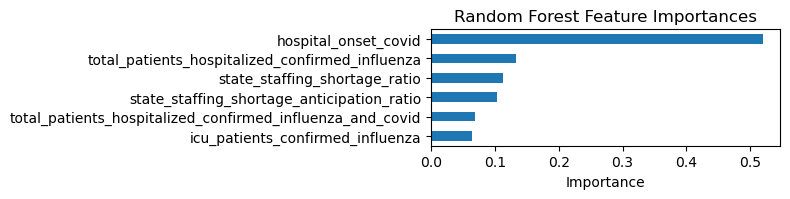

In [31]:
importances = pd.Series(rfr.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()